In [1]:
%pip install mlxtend
%pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 78.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.1 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━ 0/3 [scikit-learn]
    Found existing installation: matplotlib 3.10.70/3 [scikit-learn]
    Uninstalling matplotlib-3.10.7:━━━━━━━━━ 0/3 [scikit-learn]
      Successfully uninstalled matplotlib-3.10.7━━━━━━━━━━━━━━━━━━ 1/3 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mlxtend]m2/3 [mlxtend]ib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updat

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración para eliminar warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# CARGA DATOS

In [2]:
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Dataset: 1599 filas x 12 columnas

Valores nulos: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


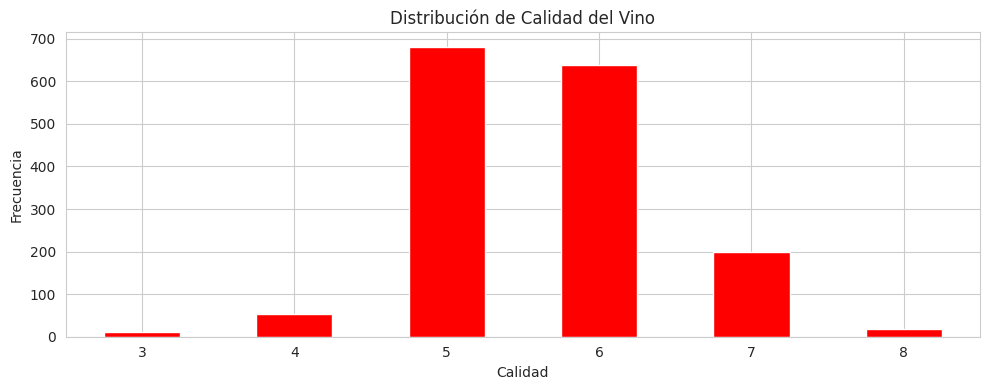

In [4]:
print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nValores nulos: {df.isnull().sum().sum()}")
display(df.head())
display(df.describe())

# Distribución de calidad original
plt.figure(figsize=(10, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', color='red')
plt.title('Distribución de Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
df.shape

(1599, 12)

DUPLICADOS

In [6]:
duplicated_rows = df.duplicated().sum()
duplicated_rows

np.int64(240)

# CREACION DE ETIQUETAS

Distribución de etiquetas:
0 (Baja): 63 (3.9%)
1 (Media): 1319 (82.5%)
2 (Alta): 217 (13.6%)


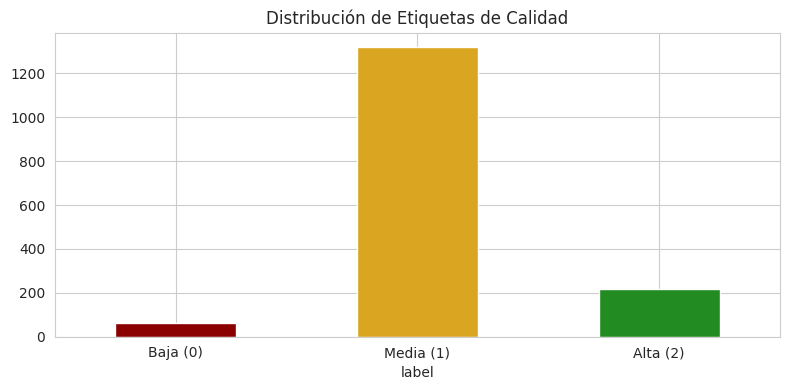

In [7]:
# Crear etiquetas
df['label'] = df['quality'].apply(lambda x: 0 if x <= 4 else (1 if x <= 6 else 2))

print("Distribución de etiquetas:")
for label, count in df['label'].value_counts().sort_index().items():
    names = {0: 'Baja', 1: 'Media', 2: 'Alta'}
    print(f"{label} ({names[label]}): {count} ({count/len(df)*100:.1f}%)")

# Visualización
plt.figure(figsize=(8, 4))
df['label'].value_counts().sort_index().plot(kind='bar', color=['#8B0000', '#DAA520', '#228B22'])
plt.title('Distribución de Etiquetas de Calidad')
plt.xticks([0, 1, 2], ['Baja (0)', 'Media (1)', 'Alta (2)'], rotation=0)
plt.tight_layout()
plt.show()

# Análisis de Correlaciones

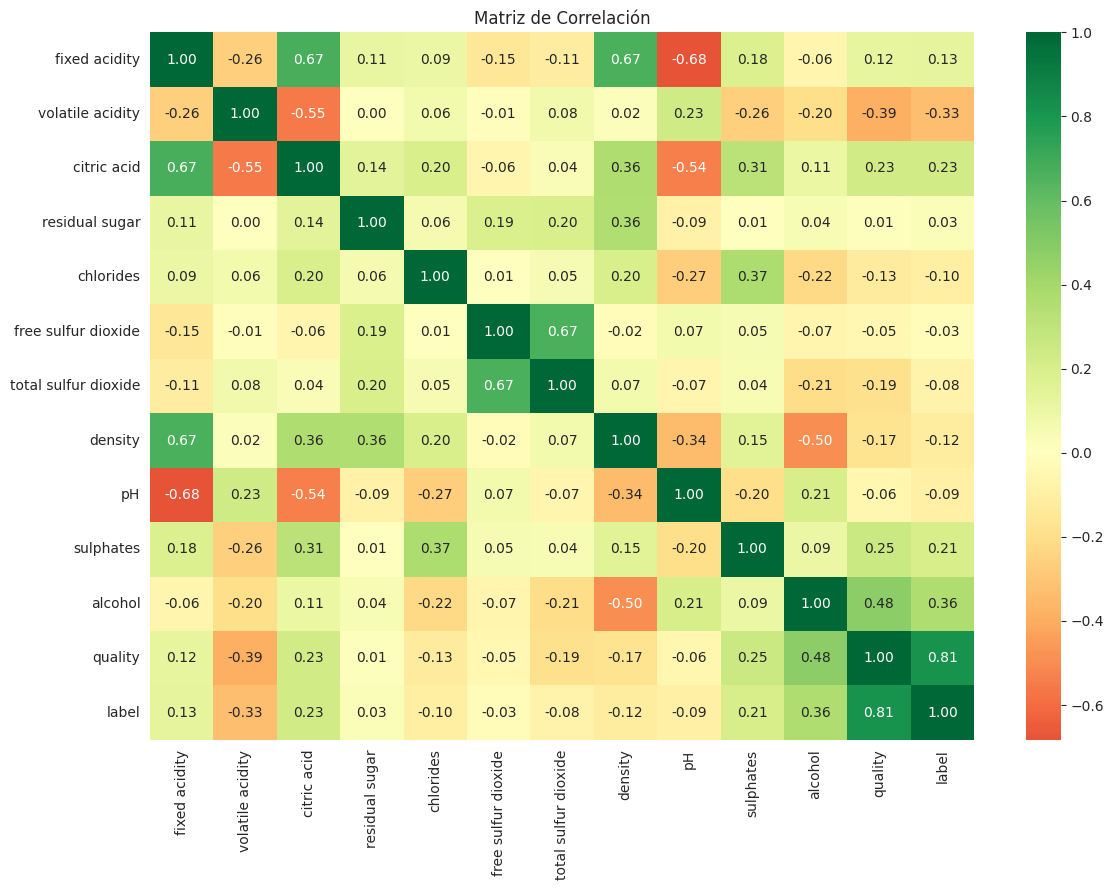


Top 5 correlaciones con 'label':
quality          0.812367
alcohol          0.361363
citric acid      0.228930
sulphates        0.205409
fixed acidity    0.125886
Name: label, dtype: float64


In [8]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

print("\nTop 5 correlaciones con 'label':")
print(df.corr()['label'].sort_values(ascending=False)[1:6])

# SEPARAR X e Y

In [10]:
X = df.drop(['quality', 'label'], axis=1)
y = df['label']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar (CRÍTICO para KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(" Datos escalados")

Train: 1279 | Test: 320
 Datos escalados


# Modelo KNN Inicial (k=5)

Accuracy (k=5): 0.8187

Reporte de Clasificación:
              precision    recall  f1-score   support

        Baja       0.00      0.00      0.00        13
       Media       0.87      0.92      0.89       264
        Alta       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



<Figure size 700x500 with 0 Axes>

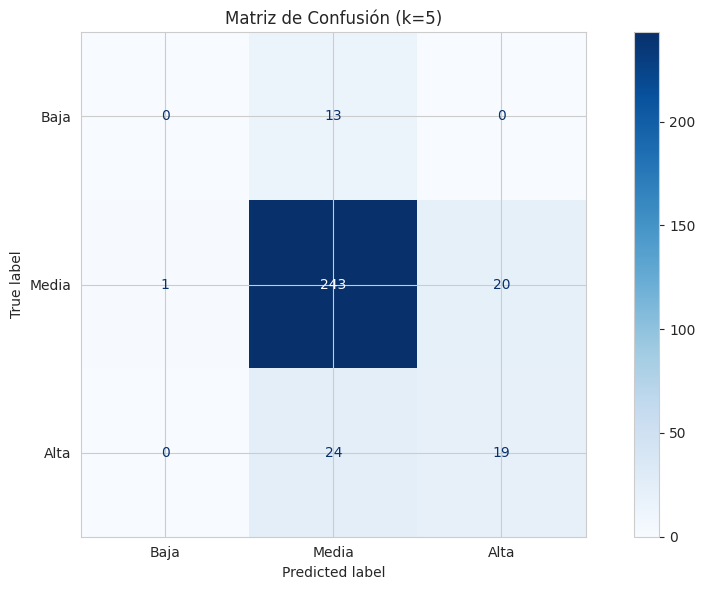

In [11]:
# Entrenar con k=5
knn_initial = KNeighborsClassifier(n_neighbors=5)
knn_initial.fit(X_train_scaled, y_train)
y_pred_initial = knn_initial.predict(X_test_scaled)

print(f"Accuracy (k=5): {accuracy_score(y_test, y_pred_initial):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_initial, target_names=['Baja', 'Media', 'Alta']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_initial)
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=['Baja', 'Media', 'Alta']).plot(cmap='Blues')
plt.title('Matriz de Confusión (k=5)')
plt.tight_layout()
plt.show()

# Optimización de k (1-20)

 Mejor k: 11 | Accuracy: 0.8594 (85.94%)


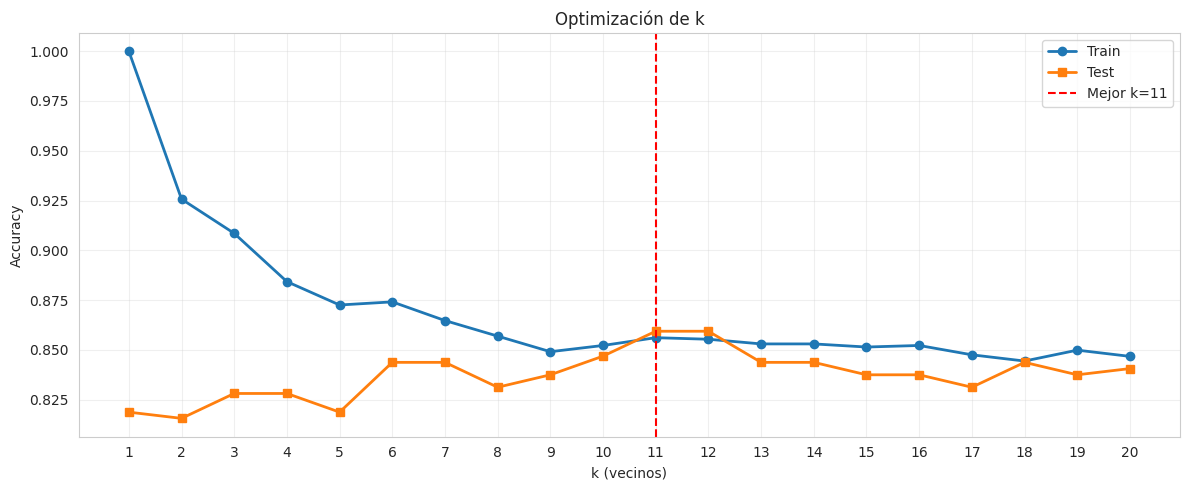

In [12]:
# Probar diferentes valores de k
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

best_k = k_range[test_scores.index(max(test_scores))]
best_accuracy = max(test_scores)

print(f" Mejor k: {best_k} | Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Gráfica de optimización
plt.figure(figsize=(12, 5))
plt.plot(k_range, train_scores, 'o-', label='Train', linewidth=2)
plt.plot(k_range, test_scores, 's-', label='Test', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
plt.xlabel('k (vecinos)')
plt.ylabel('Accuracy')
plt.title('Optimización de k')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Modelo Final (k=11)
Accuracy: 0.8594

Reporte Final:
              precision    recall  f1-score   support

        Baja       0.00      0.00      0.00        13
       Media       0.89      0.95      0.92       264
        Alta       0.64      0.58      0.61        43

    accuracy                           0.86       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.82      0.86      0.84       320



<Figure size 700x500 with 0 Axes>

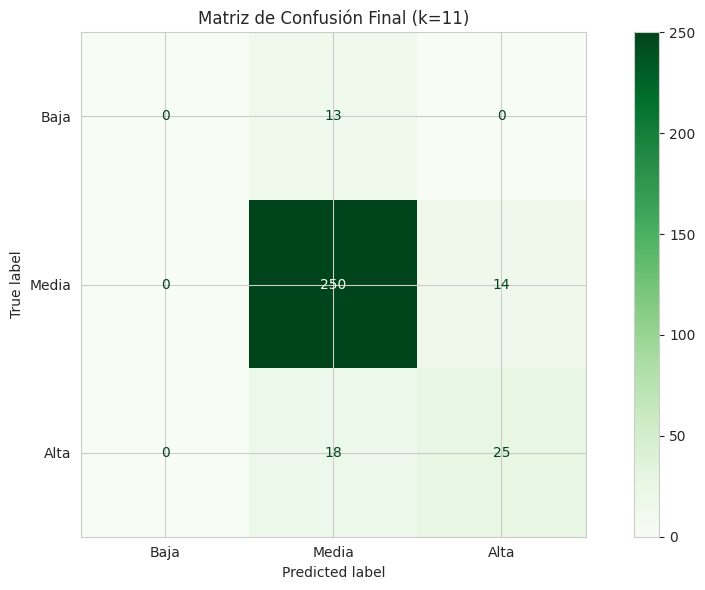

In [13]:
# Modelo final con mejor k
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred_final = final_model.predict(X_test_scaled)

print(f"Modelo Final (k={best_k})")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nReporte Final:")
print(classification_report(y_test, y_pred_final, target_names=['Baja', 'Media', 'Alta']))

# Matriz de confusión final
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay(cm_final, display_labels=['Baja', 'Media', 'Alta']).plot(cmap='Greens')
plt.title(f'Matriz de Confusión Final (k={best_k})')
plt.tight_layout()
plt.show()

# Función de Predicción

In [15]:
def predict_wine_quality(caracteristicas):
    """
    Predice calidad del vino.
    Input: lista de 11 valores [fixed acidity, volatile acidity, citric acid, 
           residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, 
           density, pH, sulphates, alcohol]
    """
    if len(caracteristicas) != 11:
        return " Error: Se requieren 11 características"
    
    scaled = scaler.transform([caracteristicas])
    pred = final_model.predict(scaled)[0]
    proba = final_model.predict_proba(scaled)[0]
    
    mensajes = {0: "BAJA CALIDAD", 1: "CALIDAD MEDIA", 2: "ALTA CALIDAD"}
    
    return f""" Este vino probablemente sea de {mensajes[pred]}

 Probabilidades:
  • Baja: {proba[0]*100:.1f}%
  • Media: {proba[1]*100:.1f}%
  • Alta: {proba[2]*100:.1f}%"""


In [17]:
# PRUEBA

wine_test = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
print(predict_wine_quality(wine_test))

# Más ejemplos
for i in range(3):
    vino = X_test.iloc[i].values.tolist()
    real = ['Baja', 'Media', 'Alta'][y_test.iloc[i]]
    print(f"\n\nEjemplo {i+1} - Real: {real}\n")
    print(predict_wine_quality(vino))

 Este vino probablemente sea de CALIDAD MEDIA

 Probabilidades:
  • Baja: 0.0%
  • Media: 100.0%
  • Alta: 0.0%


Ejemplo 1 - Real: Alta

 Este vino probablemente sea de ALTA CALIDAD

 Probabilidades:
  • Baja: 0.0%
  • Media: 9.1%
  • Alta: 90.9%


Ejemplo 2 - Real: Media

 Este vino probablemente sea de CALIDAD MEDIA

 Probabilidades:
  • Baja: 0.0%
  • Media: 100.0%
  • Alta: 0.0%


Ejemplo 3 - Real: Media

 Este vino probablemente sea de CALIDAD MEDIA

 Probabilidades:
  • Baja: 36.4%
  • Media: 63.6%
  • Alta: 0.0%
